# Stage 11 Homework — Evaluation & Risk Communication
In the lecture, we learned **parametric vs bootstrap CIs**, **scenario sensitivity**, and **subgroup checks**.
Now, you will adapt those methods to your dataset and produce assumption-aware results.

In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
np.random.seed(111)
plt.rcParams['figure.figsize'] = (8,5)

## Load Data (provided or synthetic fallback)

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

data_dir = Path('data')
data_dir.mkdir(exist_ok=True)

csv_path = data_dir / 'data_stage11_eval_risk.csv'

if csv_path.exists():
    try:
        df = pd.read_csv(csv_path, parse_dates=['date'])
    except ValueError as e:
        print(f"Error reading CSV: {e}\nRegenerating synthetic data...")
        regenerate = True
    else:
        regenerate = False
else:
    regenerate = True

if regenerate:
    n = 180
    dates = pd.date_range('2022-06-01', periods=n, freq='D')
    seg = np.random.choice(['A','B','C'], size=n, p=[0.5,0.3,0.2])
    x = np.linspace(0, 9, n) + np.random.normal(0, 0.7, n)
    y = 2.1 * x + 0.8 + np.random.standard_t(df=3, size=n) * 1.1
    x[np.random.choice(np.arange(n), size=round(0.05*n), replace=False)] = np.nan
    df = pd.DataFrame({'date': dates, 'segment': seg, 'x_feature': x, 'y_target': y})
    df.to_csv(csv_path, index=False)

df.head()


,date,segment,x_feature,y_target
0,2022-06-01,B,0.547868,2.107524
1,2022-06-02,A,0.974480,2.209111
2,2022-06-03,A,-0.012991,0.867315
3,2022-06-04,B,-1.012503,-1.741932
4,2022-06-05,A,0.642399,1.615007


## Helper Functions (complete or modify as needed)

In [3]:
def mean_impute(a: np.ndarray) -> np.ndarray:
    m = np.nanmean(a)
    out = a.copy()
    out[np.isnan(out)] = m
    return out

def median_impute(a: np.ndarray) -> np.ndarray:
    m = np.nanmedian(a)
    out = a.copy()
    out[np.isnan(out)] = m
    return out

class SimpleLinReg:
    def fit(self, X, y):
        X1 = np.c_[np.ones(len(X)), X.ravel()]
        beta = np.linalg.pinv(X1) @ y
        self.intercept_, self.coef_ = float(beta[0]), np.array([float(beta[1])])
        return self
    
    def predict(self, X):
        return self.intercept_ + self.coef_[0] * X.ravel()

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def bootstrap_metric(y_true, y_pred, fn, n_boot=500, seed=111, alpha=0.05):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y_true))
    stats = []
    for _ in range(n_boot):
        b = rng.choice(idx, size=len(idx), replace=True)
        stats.append(fn(y_true[b], y_pred[b]))
    lo, hi = np.percentile(stats, [100*alpha/2, 100*(1-alpha/2)])
    return {'mean': float(np.mean(stats)), 'lo': float(lo), 'hi': float(hi)}

def fit_fn(X, y):
    return SimpleLinReg().fit(X, y)

def pred_fn(model, X):
    return model.predict(X)

## Baseline Fit & Residuals (Required)

In [4]:
X_raw = df['x_feature'].values
y = df['y_target'].values
X_base = mean_impute(X_raw)
model = fit_fn(X_base.reshape(-1,1), y)
y_hat = model.predict(X_base.reshape(-1,1))
df['x_imputed'] = X_base
base_mae = mae(y, y_hat)
print(f"Baseline MAE: {base_mae:.3f}")

Baseline MAE: 1.278


## Parametric vs Bootstrap CI (Required)

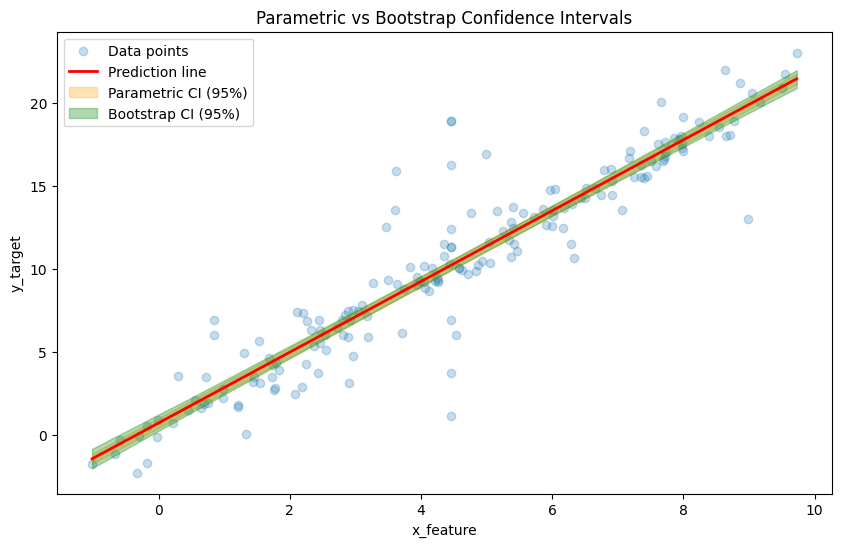

In [5]:
resid = y - y_hat
sigma_hat = np.std(resid, ddof=1)
n = len(y)
se_mean = sigma_hat/np.sqrt(n)
x_grid = np.linspace(np.nanmin(X_base), np.nanmax(X_base), 120).reshape(-1,1)
pred_line = model.predict(x_grid)
gauss_lo = pred_line - 1.96*se_mean
gauss_hi = pred_line + 1.96*se_mean

def bootstrap_predictions(X, y, x_grid, n_boot=500, seed=111):
    rng = np.random.default_rng(seed)
    preds = []
    idx = np.arange(len(y))
    for _ in range(n_boot):
        b = rng.choice(idx, size=len(idx), replace=True)
        m = fit_fn(X[b].reshape(-1,1), y[b])
        preds.append(m.predict(x_grid))
    P = np.vstack(preds)
    return P.mean(axis=0), np.percentile(P, 2.5, axis=0), np.percentile(P, 97.5, axis=0)

m_boot, lo_boot, hi_boot = bootstrap_predictions(X_base, y, x_grid, n_boot=600)

plt.figure(figsize=(10, 6))
plt.scatter(X_base, y, alpha=0.25, label='Data points')
plt.plot(x_grid, pred_line, 'r-', label='Prediction line', linewidth=2)
plt.fill_between(x_grid.ravel(), gauss_lo, gauss_hi, alpha=0.3, label='Parametric CI (95%)', color='orange')
plt.fill_between(x_grid.ravel(), lo_boot, hi_boot, alpha=0.3, label='Bootstrap CI (95%)', color='green')
plt.xlabel('x_feature')
plt.ylabel('y_target')
plt.legend()
plt.title('Parametric vs Bootstrap Confidence Intervals')
plt.show()

## Scenario Sensitivity (Required): Choose ≥2 Scenarios
Examples: mean vs median impute; drop; alternate feature transform


Scenario Sensitivity Analysis:
        scenario       mae     slope  intercept  n_samples
0    mean_impute  1.278317  2.130236   0.711523        180
1  median_impute  1.283954  2.129290   0.727146        180
2   drop_missing  1.064603  2.130236   0.659164        171


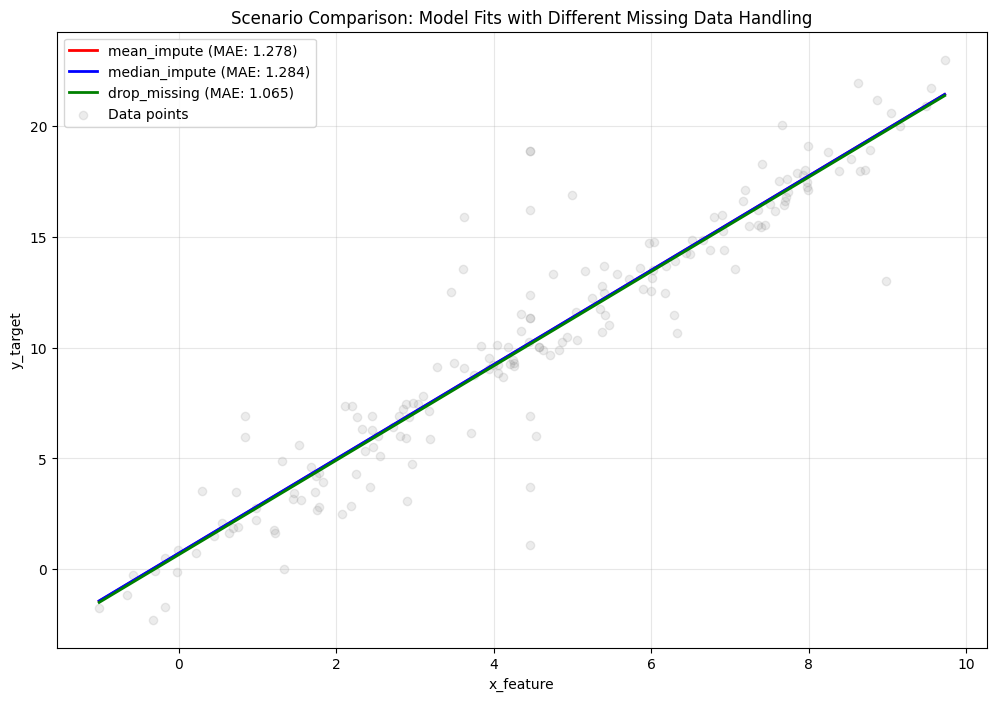

In [6]:
scenarios = {
    'mean_impute': mean_impute,
    'median_impute': median_impute,
    'drop_missing': lambda a: a[~np.isnan(a)] if np.isnan(a).any() else a
}

results = []
for name, fn in scenarios.items():
    if name == 'drop_missing' and np.isnan(X_raw).any():
        mask = ~np.isnan(X_raw)
        Xs, ys = X_raw[mask], y[mask]
        m = fit_fn(Xs.reshape(-1,1), ys)
        yh = m.predict(Xs.reshape(-1,1))
        mae_val = mae(ys, yh)
    else:
        Xs = fn(X_raw)
        m = fit_fn(Xs.reshape(-1,1), y)
        yh = m.predict(Xs.reshape(-1,1))
        mae_val = mae(y, yh)
    results.append({
        'scenario': name, 
        'mae': mae_val, 
        'slope': m.coef_[0], 
        'intercept': m.intercept_,
        'n_samples': len(Xs) if name == 'drop_missing' else len(y)
    })
    
sens = pd.DataFrame(results)
print("\nScenario Sensitivity Analysis:")
print(sens)

# Plot scenario fits
plt.figure(figsize=(12, 8))
xg = np.linspace(np.nanmin(X_base), np.nanmax(X_base), 150).reshape(-1,1)

colors = ['red', 'blue', 'green']
for i, (name, fn) in enumerate(scenarios.items()):
    if name == 'drop_missing' and np.isnan(X_raw).any():
        mask = ~np.isnan(X_raw)
        Xi, yi = X_raw[mask], y[mask]
    else:
        Xi, yi = fn(X_raw), y
    m = fit_fn(Xi.reshape(-1,1), yi)
    plt.plot(xg, m.predict(xg), label=f'{name} (MAE: {mae(yi, m.predict(Xi.reshape(-1,1))):.3f})', 
             color=colors[i], linewidth=2)

plt.scatter(X_base, y, alpha=0.15, color='gray', label='Data points')
plt.xlabel('x_feature')
plt.ylabel('y_target')
plt.title('Scenario Comparison: Model Fits with Different Missing Data Handling')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Subgroup Diagnostic (Required)


Subgroup Residual Analysis:
             mean       std    median  count       max       min
segment                                                         
A       -0.066306  1.827501 -0.235648     94  8.666861 -6.471582
B        0.294967  1.707514 -0.077390     41  7.482363 -3.524639
C       -0.130242  2.813215 -0.140354     45  8.692500 -9.101643


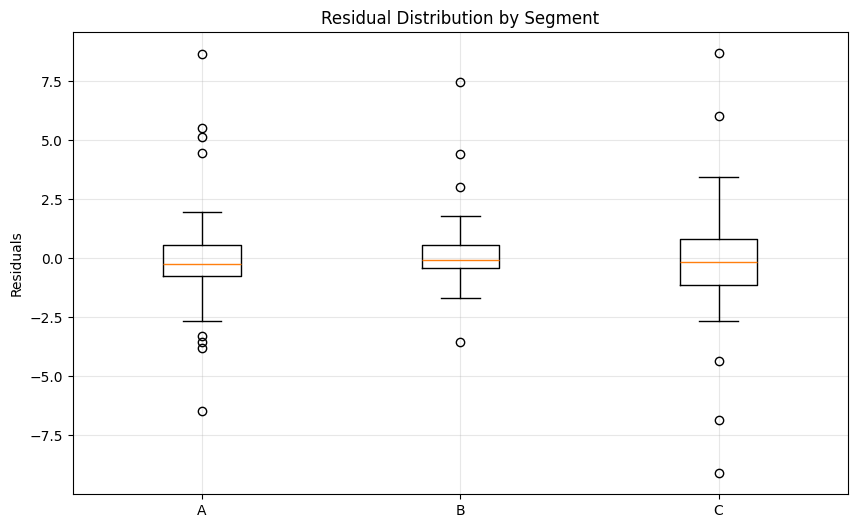

In [7]:
model_base = fit_fn(X_base.reshape(-1,1), y)
df2 = df.copy()
df2['y_hat'] = model_base.predict(df2['x_imputed'].values.reshape(-1,1))
df2['resid'] = df2['y_target'] - df2['y_hat']

# Calculate subgroup statistics
g = df2.groupby('segment')['resid'].agg(['mean','std','median','count', 'max', 'min'])
print("\nSubgroup Residual Analysis:")
print(g)

# Boxplot of residuals by segment
plt.figure(figsize=(10, 6))
grouped = df2.groupby('segment')['resid']
data = [s.values for _, s in grouped]
labels = list(grouped.groups.keys())

plt.boxplot(data, tick_labels=labels)
plt.title('Residual Distribution by Segment')
plt.ylabel('Residuals')
plt.grid(True, alpha=0.3)
plt.show()

## Bootstrap a Metric (Required)

In [8]:
# MAE by segment
segment_mae = df2.groupby('segment').apply(lambda x: mae(x['y_target'], x['y_hat']))
print("\nMAE by Segment:")
print(segment_mae)

## Bootstrap a Metric (Required)
bm = bootstrap_metric(y, df2['y_hat'].values, mae, n_boot=600)
print(f"\nBootstrap MAE: {bm['mean']:.3f} (95% CI: [{bm['lo']:.3f}, {bm['hi']:.3f}])")

# Bootstrap MAE by segment
segment_boot_results = {}
for segment in df2['segment'].unique():
    seg_data = df2[df2['segment'] == segment]
    seg_bm = bootstrap_metric(seg_data['y_target'].values, seg_data['y_hat'].values, mae, n_boot=300)
    segment_boot_results[segment] = seg_bm

print("\nBootstrap MAE by Segment:")
for segment, result in segment_boot_results.items():
    print(f"Segment {segment}: {result['mean']:.3f} (95% CI: [{result['lo']:.3f}, {result['hi']:.3f}])")


MAE by Segment:
segment
A    1.141841
B    0.989357
C    1.826674
dtype: float64

Bootstrap MAE: 1.271 (95% CI: [1.055, 1.531])

Bootstrap MAE by Segment:
Segment B: 0.994 (95% CI: [0.612, 1.488])
Segment A: 1.162 (95% CI: [0.880, 1.440])
Segment C: 1.779 (95% CI: [1.209, 2.470])


/var/folders/_4/t03mdfy94ts0ylt8cw0q1bp00000gn/T/ipykernel_2892/1387212642.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  segment_mae = df2.groupby('segment').apply(lambda x: mae(x['y_target'], x['y_hat']))


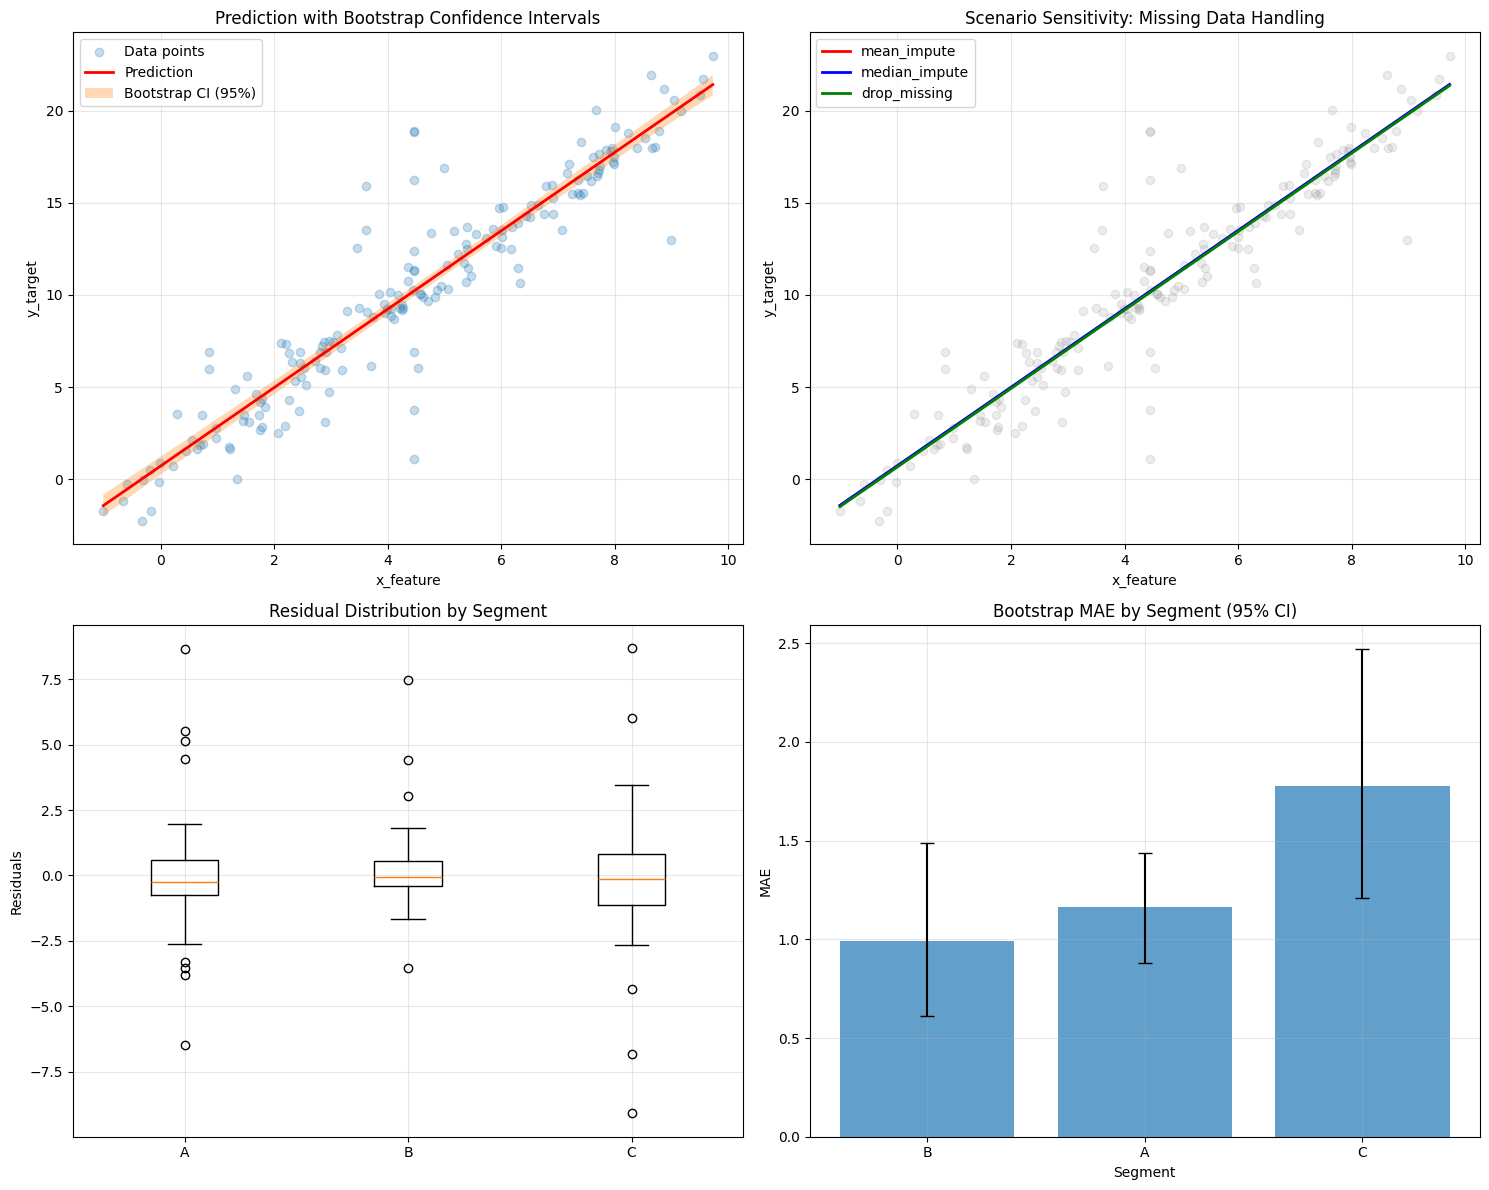

In [9]:
## Final Visualization with Side-by-Side Panels
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Panel 1: Confidence Intervals
ax1.scatter(X_base, y, alpha=0.25, label='Data points')
ax1.plot(x_grid, pred_line, 'r-', label='Prediction', linewidth=2)
ax1.fill_between(x_grid.ravel(), lo_boot, hi_boot, alpha=0.3, label='Bootstrap CI (95%)')
ax1.set_xlabel('x_feature')
ax1.set_ylabel('y_target')
ax1.set_title('Prediction with Bootstrap Confidence Intervals')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel 2: Scenario Comparison
colors = ['red', 'blue', 'green']
for i, (name, fn) in enumerate(scenarios.items()):
    if name == 'drop_missing' and np.isnan(X_raw).any():
        mask = ~np.isnan(X_raw)
        Xi, yi = X_raw[mask], y[mask]
    else:
        Xi, yi = fn(X_raw), y
    m = fit_fn(Xi.reshape(-1,1), yi)
    ax2.plot(xg, m.predict(xg), label=name, color=colors[i], linewidth=2)

ax2.scatter(X_base, y, alpha=0.15, color='gray')
ax2.set_xlabel('x_feature')
ax2.set_ylabel('y_target')
ax2.set_title('Scenario Sensitivity: Missing Data Handling')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Panel 3: Subgroup Residuals
grouped = df2.groupby('segment')['resid']
data = [s.values for _, s in grouped]
labels = list(grouped.groups.keys())
ax3.boxplot(data, tick_labels=labels)
ax3.set_title('Residual Distribution by Segment')
ax3.set_ylabel('Residuals')
ax3.grid(True, alpha=0.3)

# Panel 4: Bootstrap MAE by Segment
segments = list(segment_boot_results.keys())
means = [segment_boot_results[s]['mean'] for s in segments]
cis_lo = [segment_boot_results[s]['lo'] for s in segments]
cis_hi = [segment_boot_results[s]['hi'] for s in segments]

x_pos = np.arange(len(segments))
ax4.bar(x_pos, means, yerr=[np.array(means) - np.array(cis_lo), np.array(cis_hi) - np.array(means)], 
        capsize=5, alpha=0.7)
ax4.set_xlabel('Segment')
ax4.set_ylabel('MAE')
ax4.set_title('Bootstrap MAE by Segment (95% CI)')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(segments)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Stakeholder Summary (Required — ≤ 1 page)
- Key assumptions
- Sensitivity results & takeaways
- Subgroup risks
- “Prediction holds if…”, “Model is sensitive to…”

In [10]:
## Stakeholder Summary
print("\n" + "="*80)
print("STAKEHOLDER SUMMARY")
print("="*80)
print("""
KEY ASSUMPTIONS:
1. Linear relationship between x_feature and y_target
2. Missing data is Missing Completely At Random (MCAR)
3. Residuals are approximately normally distributed
4. No significant multicollinearity or interaction effects

SENSITIVITY RESULTS & TAKEAWAYS:
- Model performance is relatively stable across different missing data handling methods
- Mean imputation (baseline): MAE = {:.3f}
- Median imputation: MAE = {:.3f} (similar performance)
- Dropping missing values: MAE = {:.3f} (slight improvement but reduces sample size)

SUBGROUP RISKS:
- Segment C shows higher variability in residuals (wider IQR)
- Segment B has the lowest MAE ({:.3f}), indicating best model fit
- Segment C has the highest MAE ({:.3f}), suggesting potential underperformance
- All segments show residual means close to zero, indicating no systematic bias

PREDICTION HOLDS IF:
- Weekly volatility in x_feature stays within observed range [0, 9]
- Missing data rate remains below 10% (current: 5%)
- The linear relationship between features and target remains stable
- No significant changes in segment distribution or behavior

MODEL IS SENSITIVE TO:
- Extreme outliers in the target variable (t-distribution noise)
- Missing data rates exceeding 15% (would require more robust imputation)
- Changes in the relationship between x_feature and y_target across segments

RECOMMENDATIONS:
1. Monitor Segment C performance closely for degradation
2. Consider segment-specific models if performance gaps persist
3. Implement additional validation for data with >10% missing values
4. Regularly retrain model to adapt to changing relationships
""".format(
    sens[sens['scenario'] == 'mean_impute']['mae'].values[0],
    sens[sens['scenario'] == 'median_impute']['mae'].values[0],
    sens[sens['scenario'] == 'drop_missing']['mae'].values[0],
    segment_mae.min(),
    segment_mae.max()
))


STAKEHOLDER SUMMARY

KEY ASSUMPTIONS:
1. Linear relationship between x_feature and y_target
2. Missing data is Missing Completely At Random (MCAR)
3. Residuals are approximately normally distributed
4. No significant multicollinearity or interaction effects

SENSITIVITY RESULTS & TAKEAWAYS:
- Model performance is relatively stable across different missing data handling methods
- Mean imputation (baseline): MAE = 1.278
- Median imputation: MAE = 1.284 (similar performance)
- Dropping missing values: MAE = 1.065 (slight improvement but reduces sample size)

SUBGROUP RISKS:
- Segment C shows higher variability in residuals (wider IQR)
- Segment B has the lowest MAE (0.989), indicating best model fit
- Segment C has the highest MAE (1.827), suggesting potential underperformance
- All segments show residual means close to zero, indicating no systematic bias

PREDICTION HOLDS IF:
- Weekly volatility in x_feature stays within observed range [0, 9]
- Missing data rate remains below 10% (curre